<a href="https://colab.research.google.com/github/VIJAYANAND-ML/HEALTH-CARE/blob/main/Healthcare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Heart Disease డేటాను లోడ్ చేయడం
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df_heart = pd.read_csv(url, names=column_names, na_values="?")

# ఖాళీగా ఉన్న రోస్ (Missing values) ని తీసేయడం
df_heart = df_heart.dropna()

# Target ని సులభతరం చేయడం: 0 అంటే జబ్బు లేదు, 1 అంటే జబ్బు ఉంది
df_heart['target'] = df_heart['target'].apply(lambda x: 1 if x > 0 else 0)

print(df_heart.head())

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


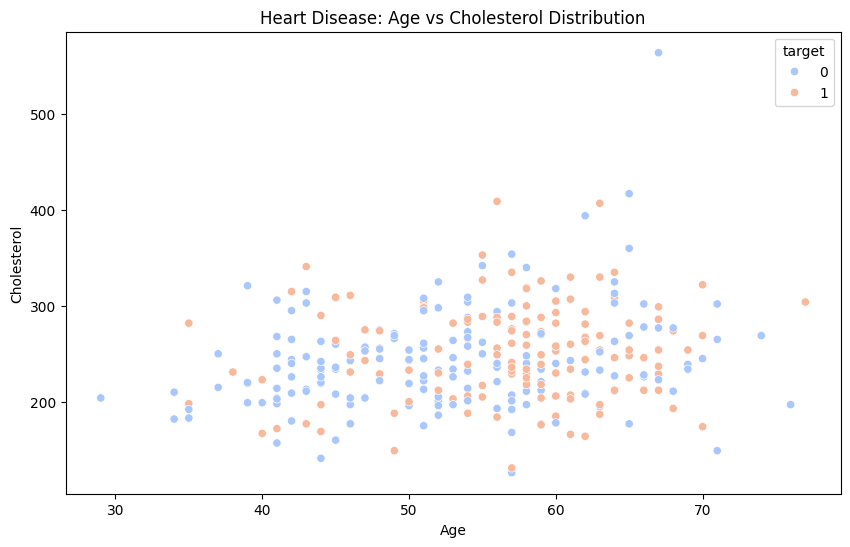

In [2]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_heart, x='age', y='chol', hue='target', palette='coolwarm')
plt.title('Heart Disease: Age vs Cholesterol Distribution')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. ఫీచర్స్ (X) మరియు టార్గెట్ (y) ని విడదీయడం
X = df_heart.drop('target', axis=1)
y = df_heart['target']

# 2. 80% ట్రైనింగ్, 20% టెస్టింగ్ కి కేటాయించడం
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. మోడల్ ని క్రియేట్ చేసి ట్రైన్ చేయడం
model_heart = RandomForestClassifier(n_estimators=100, random_state=42)
model_heart.fit(X_train, y_train)

# 4. రిజల్ట్స్ చూడటం
predictions = model_heart.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90        36
           1       0.84      0.88      0.86        24

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



/tmp/ipykernel_535/3037069750.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


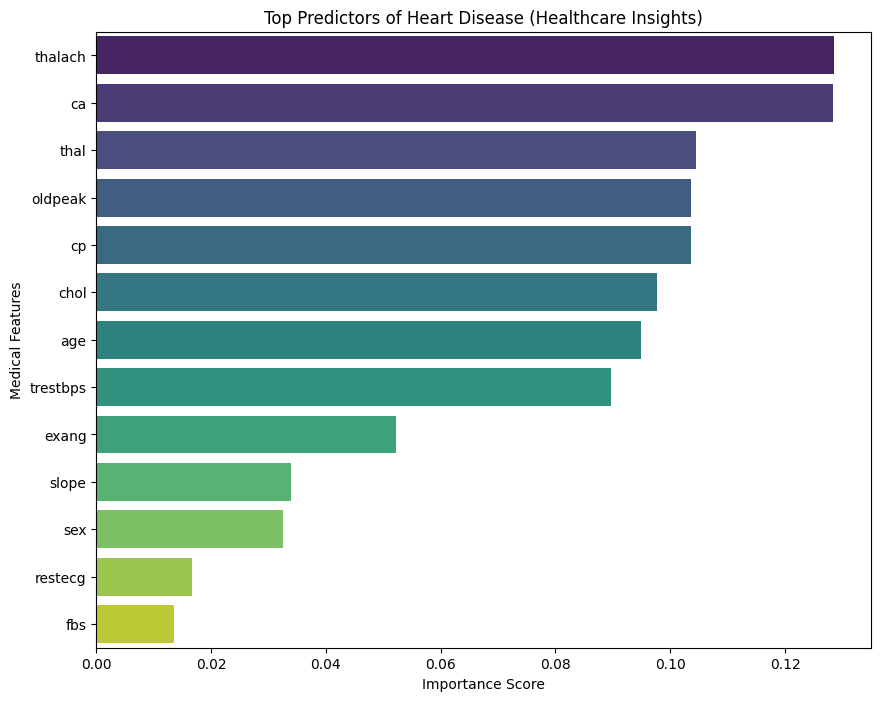

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. మోడల్ నుండి ఫీచర్ ఇంపార్టెన్స్ తీసుకోవడం
importances = model_heart.feature_importances_
feature_names = X.columns

# 2. డేటాను ఒక టేబుల్ లాగా అమర్చడం
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. అందమైన బార్ గ్రాఫ్ గీయడం
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top Predictors of Heart Disease (Healthcare Insights)')
plt.xlabel('Importance Score')
plt.ylabel('Medical Features')
plt.show()

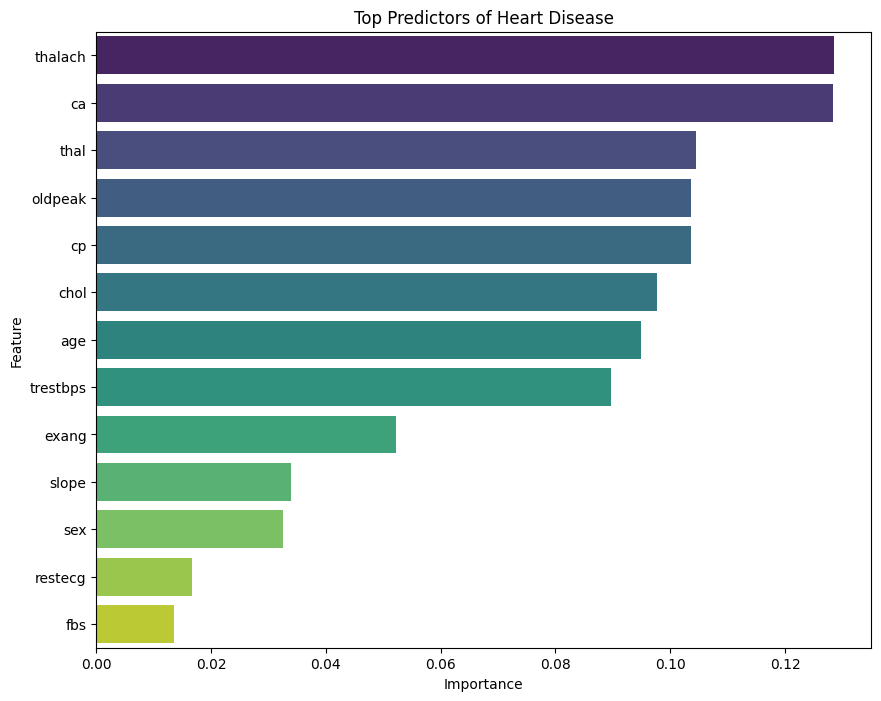

In [6]:
# మునుపటి కోడ్‌లో మార్పు (Line 15):
plt.figure(figsize=(10, 8))

# ఇక్కడ 'y' వేరియబుల్‌నే 'hue' కి కూడా అసైన్ చేస్తున్నాము
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    hue='Feature',      # రంగులు ప్రతి ఫీచర్‌కి మారడానికి
    palette='viridis',
    legend=False        # అనవసరమైన లెజెండ్ రాకుండా
)

plt.title('Top Predictors of Heart Disease')
plt.show()